In [1]:
!pip install numpy pandas matplotlib scipy


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Load all NCU data

In [2]:
import pandas as pd

metrics_df_raw: pd.DataFrame = pd.read_csv('metrics/metrics_all_ncu.csv')
metrics_df_raw

,GpuName,SeqLen,HeadDim,Run,Range,Action,dram__bytes_read.sum,dram__bytes_write.sum,dram__cycles_active.avg,gpu__time_duration.sum,...,smsp__pcsamp_warps_issue_stalled_short_scoreboard,smsp__warps_issue_stalled_long_scoreboard.avg,smsp__warps_issue_stalled_math_pipe_throttle.avg,smsp__warps_issue_stalled_mio_throttle.avg,smsp__warps_issue_stalled_not_selected.avg,smsp__warps_issue_stalled_short_scoreboard.avg,smsp__warps_issue_stalled_wait.avg,sm__pipe_aluheavy_cycles_active.avg,sm__pipe_fmaheavy_cycles_active.avg,sm__pipe_fmalite_cycles_active.avg
0,a100-sxm4-40gb,256,64,0,0,unrolled_elementwise_kernel,64896.0,0.0,50.7,7232.0,...,2.0,6.225278e+02,0.000000e+00,0.00000,0.000000e+00,29.870370,2.408935e+02,NaN,NaN,NaN
1,a100-sxm4-40gb,256,64,0,0,unrolled_elementwise_kernel,64896.0,0.0,50.7,7136.0,...,1.0,6.214144e+02,0.000000e+00,0.00000,0.000000e+00,29.833333,2.408935e+02,NaN,NaN,NaN
2,a100-sxm4-40gb,256,64,0,0,unrolled_elementwise_kernel,64896.0,0.0,50.7,7264.0,...,1.0,6.278171e+02,0.000000e+00,0.00000,0.000000e+00,29.861111,2.408935e+02,NaN,NaN,NaN
3,a100-sxm4-40gb,256,64,0,0,vectorized_elementwise_kernel,70272.0,0.0,54.9,3680.0,...,0.0,1.010463e+02,0.000000e+00,0.00000,0.000000e+00,1.629630,1.111574e+01,NaN,NaN,NaN
4,a100-sxm4-40gb,256,64,0,0,vectorized_elementwise_kernel,70272.0,0.0,54.9,3616.0,...,0.0,8.603241e+01,0.000000e+00,0.00000,0.000000e+00,1.629630,1.111111e+01,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3772,t4,8192,128,2,0,volta_sgemm_128x64_nn,589915936.0,25986368.0,9623473.5,5934784.0,...,562.0,7.850871e+04,3.941911e+06,339227.01250,3.958977e+06,51570.875000,1.556352e+06,NaN,NaN,NaN
3773,t4,8192,128,2,0,vectorized_elementwise_kernel,4586720.0,1341952.0,92635.5,24000.0,...,14.0,5.316704e+04,1.454000e+02,220.89375,2.123063e+02,1062.081250,3.360969e+03,NaN,NaN,NaN
3774,t4,8192,128,0,0,fmha_cutlassF_f16_aligned_32x128_rf_sm75,22699488.0,3729152.0,412947.5,5588640.0,...,18286.0,1.074158e+06,1.913800e+05,384953.62500,1.077445e+05,903370.456250,1.209923e+06,NaN,NaN,NaN
3775,t4,8192,128,1,0,fmha_cutlassF_f16_aligned_32x128_rf_sm75,22625728.0,3719264.0,411640.5,5589024.0,...,18211.0,1.066248e+06,1.913814e+05,383457.90625,1.074397e+05,906406.893750,1.209805e+06,NaN,NaN,NaN


In [3]:
# convert stall cols to proportions instead of raw sample counts
stall_cols = [c for c in metrics_df_raw.columns if c.startswith('smsp__pcsamp_warps_issue_stalled_')]
metrics_df = metrics_df_raw.copy()
total_samples = metrics_df_raw[stall_cols].sum(axis=1)
metrics_df[stall_cols] = metrics_df_raw[stall_cols].div(total_samples, axis=0)
metrics_df

,GpuName,SeqLen,HeadDim,Run,Range,Action,dram__bytes_read.sum,dram__bytes_write.sum,dram__cycles_active.avg,gpu__time_duration.sum,...,smsp__pcsamp_warps_issue_stalled_short_scoreboard,smsp__warps_issue_stalled_long_scoreboard.avg,smsp__warps_issue_stalled_math_pipe_throttle.avg,smsp__warps_issue_stalled_mio_throttle.avg,smsp__warps_issue_stalled_not_selected.avg,smsp__warps_issue_stalled_short_scoreboard.avg,smsp__warps_issue_stalled_wait.avg,sm__pipe_aluheavy_cycles_active.avg,sm__pipe_fmaheavy_cycles_active.avg,sm__pipe_fmalite_cycles_active.avg
0,a100-sxm4-40gb,256,64,0,0,unrolled_elementwise_kernel,64896.0,0.0,50.7,7232.0,...,0.046512,6.225278e+02,0.000000e+00,0.00000,0.000000e+00,29.870370,2.408935e+02,NaN,NaN,NaN
1,a100-sxm4-40gb,256,64,0,0,unrolled_elementwise_kernel,64896.0,0.0,50.7,7136.0,...,0.023256,6.214144e+02,0.000000e+00,0.00000,0.000000e+00,29.833333,2.408935e+02,NaN,NaN,NaN
2,a100-sxm4-40gb,256,64,0,0,unrolled_elementwise_kernel,64896.0,0.0,50.7,7264.0,...,0.022222,6.278171e+02,0.000000e+00,0.00000,0.000000e+00,29.861111,2.408935e+02,NaN,NaN,NaN
3,a100-sxm4-40gb,256,64,0,0,vectorized_elementwise_kernel,70272.0,0.0,54.9,3680.0,...,0.000000,1.010463e+02,0.000000e+00,0.00000,0.000000e+00,1.629630,1.111574e+01,NaN,NaN,NaN
4,a100-sxm4-40gb,256,64,0,0,vectorized_elementwise_kernel,70272.0,0.0,54.9,3616.0,...,0.000000,8.603241e+01,0.000000e+00,0.00000,0.000000e+00,1.629630,1.111111e+01,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3772,t4,8192,128,2,0,volta_sgemm_128x64_nn,589915936.0,25986368.0,9623473.5,5934784.0,...,0.006962,7.850871e+04,3.941911e+06,339227.01250,3.958977e+06,51570.875000,1.556352e+06,NaN,NaN,NaN
3773,t4,8192,128,2,0,vectorized_elementwise_kernel,4586720.0,1341952.0,92635.5,24000.0,...,0.036554,5.316704e+04,1.454000e+02,220.89375,2.123063e+02,1062.081250,3.360969e+03,NaN,NaN,NaN
3774,t4,8192,128,0,0,fmha_cutlassF_f16_aligned_32x128_rf_sm75,22699488.0,3729152.0,412947.5,5588640.0,...,0.393417,1.074158e+06,1.913800e+05,384953.62500,1.077445e+05,903370.456250,1.209923e+06,NaN,NaN,NaN
3775,t4,8192,128,1,0,fmha_cutlassF_f16_aligned_32x128_rf_sm75,22625728.0,3719264.0,411640.5,5589024.0,...,0.394246,1.066248e+06,1.913814e+05,383457.90625,1.074397e+05,906406.893750,1.209805e+06,NaN,NaN,NaN


In [4]:
metrics_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3777 entries, 0 to 3776
Data columns (total 52 columns):
 #   Column                                                         Non-Null Count  Dtype  
---  ------                                                         --------------  -----  
 0   GpuName                                                        3777 non-null   str    
 1   SeqLen                                                         3777 non-null   int64  
 2   HeadDim                                                        3777 non-null   int64  
 3   Run                                                            3777 non-null   int64  
 4   Range                                                          3777 non-null   int64  
 5   Action                                                         3777 non-null   str    
 6   dram__bytes_read.sum                                           3777 non-null   float64
 7   dram__bytes_write.sum                                          3777 non

In [5]:
LABEL_COLS = ['GpuName', 'SeqLen', 'HeadDim', 'Run', 'Action', 'Range']

In [6]:
RAW_CYCLE_COLS = {
    'SM_Util': 'sm__cycles_active.avg',
    'Tensor_Util': 'sm__pipe_tensor_cycles_active.avg',
    'FMA_Util': 'sm__pipe_fma_cycles_active.avg',
    'FMA_Heavy_Util': 'sm__pipe_fmaheavy_cycles_active.avg',
    'FMA_Lite_Util': 'sm__pipe_fmalite_cycles_active.avg',
    'Shared_Util': 'sm__pipe_shared_cycles_active.avg',
    'ALU_Util': 'sm__pipe_alu_cycles_active.avg',
    'ALU_Heavy_Util': 'sm__pipe_aluheavy_cycles_active.avg',
    'FP64_Util': 'sm__pipe_fp64_cycles_active.avg',
    'L1_Cache_Util': 'l1tex__cycles_active.avg',
    'LTS_Util': 'lts__cycles_active.avg',
    'DRAM_Util': 'dram__cycles_active.avg',
}

# Percent-of-peak metrics require weighted-average aggregation:
#   weighted_util = sum((U_i / 100) * elapsed_i) / sum(elapsed_i)
PCT_COLS = {
    'SFU_Util': 'smsp__inst_executed_pipe_xu.avg.pct_of_peak_sustained_elapsed',
    'SMSP_Util': 'smsp__issue_active.avg.pct_of_peak_sustained_elapsed',
}

In [7]:
metrics_df_run0 = metrics_df[metrics_df['Run'] == 0].reset_index(drop=True)
metrics_df_run1 = metrics_df[metrics_df['Run'] == 1].reset_index(drop=True)
metrics_df_run2 = metrics_df[metrics_df['Run'] == 2].reset_index(drop=True)
metrics_df_run0

,GpuName,SeqLen,HeadDim,Run,Range,Action,dram__bytes_read.sum,dram__bytes_write.sum,dram__cycles_active.avg,gpu__time_duration.sum,...,smsp__pcsamp_warps_issue_stalled_short_scoreboard,smsp__warps_issue_stalled_long_scoreboard.avg,smsp__warps_issue_stalled_math_pipe_throttle.avg,smsp__warps_issue_stalled_mio_throttle.avg,smsp__warps_issue_stalled_not_selected.avg,smsp__warps_issue_stalled_short_scoreboard.avg,smsp__warps_issue_stalled_wait.avg,sm__pipe_aluheavy_cycles_active.avg,sm__pipe_fmaheavy_cycles_active.avg,sm__pipe_fmalite_cycles_active.avg
0,a100-sxm4-40gb,256,64,0,0,unrolled_elementwise_kernel,64896.0,0.0,50.7,7232.0,...,0.046512,6.225278e+02,0.000000e+00,0.00000,0.000000e+00,29.870370,2.408935e+02,NaN,NaN,NaN
1,a100-sxm4-40gb,256,64,0,0,unrolled_elementwise_kernel,64896.0,0.0,50.7,7136.0,...,0.023256,6.214144e+02,0.000000e+00,0.00000,0.000000e+00,29.833333,2.408935e+02,NaN,NaN,NaN
2,a100-sxm4-40gb,256,64,0,0,unrolled_elementwise_kernel,64896.0,0.0,50.7,7264.0,...,0.022222,6.278171e+02,0.000000e+00,0.00000,0.000000e+00,29.861111,2.408935e+02,NaN,NaN,NaN
3,a100-sxm4-40gb,256,64,0,0,vectorized_elementwise_kernel,70272.0,0.0,54.9,3680.0,...,0.000000,1.010463e+02,0.000000e+00,0.00000,0.000000e+00,1.629630,1.111574e+01,NaN,NaN,NaN
4,a100-sxm4-40gb,256,64,0,0,vectorized_elementwise_kernel,70272.0,0.0,54.9,3616.0,...,0.000000,8.603241e+01,0.000000e+00,0.00000,0.000000e+00,1.629630,1.111111e+01,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1254,t4,8192,128,0,0,elementwise_kernel,315854144.0,301254784.0,9642327.0,2318112.0,...,0.018352,6.350422e+06,2.237983e+05,777.31250,3.433674e+05,148902.925000,1.318696e+06,NaN,NaN,NaN
1255,t4,8192,128,0,0,vectorized_elementwise_kernel,294650528.0,149999232.0,6947652.5,1572160.0,...,0.019029,6.176007e+06,1.480906e+03,35835.81875,9.249038e+03,107273.475000,2.115415e+05,NaN,NaN,NaN
1256,t4,8192,128,0,0,volta_sgemm_128x64_nn,589931488.0,25997888.0,9623896.5,5936864.0,...,0.006738,7.869395e+04,3.936992e+06,339920.79375,3.957118e+06,51954.100000,1.556326e+06,NaN,NaN,NaN
1257,t4,8192,128,0,0,vectorized_elementwise_kernel,4585088.0,1346880.0,92687.0,24096.0,...,0.019284,5.322488e+04,1.412812e+02,212.18125,2.137125e+02,1073.031250,3.361575e+03,NaN,NaN,NaN


## Compare runs for sanity check

In [8]:
import numpy as np
from scipy.stats import variation

data_cols = [c for c in metrics_df_run0.columns if c not in LABEL_COLS]

# Stack runs along axis 0 → shape (3, n_rows, n_data_cols)
stacked = np.stack([
    metrics_df_run0[data_cols].values,
    metrics_df_run1[data_cols].values,
    metrics_df_run2[data_cols].values
], axis=0)

# CV = std/mean across the 3 runs for each (row, metric) pair
diff_df = metrics_df_run0[LABEL_COLS].copy()
diff_df[data_cols] = variation(stacked, axis=0)

diff_df

,GpuName,SeqLen,HeadDim,Run,Action,Range,dram__bytes_read.sum,dram__bytes_write.sum,dram__cycles_active.avg,gpu__time_duration.sum,...,smsp__pcsamp_warps_issue_stalled_short_scoreboard,smsp__warps_issue_stalled_long_scoreboard.avg,smsp__warps_issue_stalled_math_pipe_throttle.avg,smsp__warps_issue_stalled_mio_throttle.avg,smsp__warps_issue_stalled_not_selected.avg,smsp__warps_issue_stalled_short_scoreboard.avg,smsp__warps_issue_stalled_wait.avg,sm__pipe_aluheavy_cycles_active.avg,sm__pipe_fmaheavy_cycles_active.avg,sm__pipe_fmalite_cycles_active.avg
0,a100-sxm4-40gb,256,64,0,unrolled_elementwise_kernel,0,0.000000,NaN,1.401465e-16,0.021566,...,0.188599,0.007305,NaN,NaN,NaN,0.000877,0.000000e+00,NaN,NaN,NaN
1,a100-sxm4-40gb,256,64,0,unrolled_elementwise_kernel,0,0.000000,NaN,1.401465e-16,0.012669,...,0.537832,0.004382,NaN,NaN,NaN,0.001722,0.000000e+00,NaN,NaN,NaN
2,a100-sxm4-40gb,256,64,0,unrolled_elementwise_kernel,0,0.000000,NaN,1.401465e-16,0.012613,...,0.365471,0.005544,NaN,NaN,NaN,0.000669,0.000000e+00,NaN,NaN,NaN
3,a100-sxm4-40gb,256,64,0,vectorized_elementwise_kernel,0,0.000000,NaN,0.000000e+00,0.004111,...,NaN,0.024275,NaN,NaN,NaN,0.000000,0.000000e+00,NaN,NaN,NaN
4,a100-sxm4-40gb,256,64,0,vectorized_elementwise_kernel,0,0.000000,NaN,0.000000e+00,0.000000,...,NaN,0.005291,NaN,NaN,NaN,0.000000,1.598721e-16,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1254,t4,8192,128,0,elementwise_kernel,0,0.000134,0.000068,1.018202e-04,0.000181,...,0.003303,0.000389,0.001921,0.015893,0.002323,0.000669,3.373576e-05,NaN,NaN,NaN
1255,t4,8192,128,0,vectorized_elementwise_kernel,0,0.000497,0.000339,2.146477e-04,0.000308,...,0.053169,0.000567,0.002002,0.013118,0.002043,0.021039,1.047420e-04,NaN,NaN,NaN
1256,t4,8192,128,0,volta_sgemm_128x64_nn,0,0.000332,0.000322,3.299812e-04,0.000169,...,0.013356,0.000969,0.000758,0.002035,0.000364,0.003142,8.164633e-06,NaN,NaN,NaN
1257,t4,8192,128,0,vectorized_elementwise_kernel,0,0.000675,0.006125,8.614604e-04,0.002739,...,0.480813,0.000508,0.011742,0.033960,0.003915,0.007096,1.961957e-04,NaN,NaN,NaN


In [9]:
threshold = 0.03
data_cols = [c for c in diff_df.columns if c not in LABEL_COLS]

flagged = (
    diff_df[data_cols]
    .stack()
    .reset_index()
    .rename(columns={'level_1': 'metric', 0: 'cv'})
    .query('cv >= @threshold')
)

label_vals = diff_df.loc[flagged['level_0'], LABEL_COLS].reset_index(drop=True)
flagged_df = pd.concat([label_vals, flagged[['metric', 'cv']].reset_index(drop=True)], axis=1)
flagged_df

,GpuName,SeqLen,HeadDim,Run,Action,Range,metric,cv
0,a100-sxm4-40gb,256,64,0,unrolled_elementwise_kernel,0,lts__t_sector_hit_rate.pct,0.154310
1,a100-sxm4-40gb,256,64,0,unrolled_elementwise_kernel,0,lts__t_sectors.sum,0.075258
2,a100-sxm4-40gb,256,64,0,unrolled_elementwise_kernel,0,smsp__pcsamp_warps_issue_stalled_short_scoreboard,0.188599
3,a100-sxm4-40gb,256,64,0,unrolled_elementwise_kernel,0,lts__t_sector_hit_rate.pct,0.079990
4,a100-sxm4-40gb,256,64,0,unrolled_elementwise_kernel,0,smsp__pcsamp_warps_issue_stalled_long_scoreboard,0.039925
...,...,...,...,...,...,...,...,...
4691,t4,8192,128,0,volta_sgemm_128x64_nn,0,smsp__pcsamp_warps_issue_stalled_lg_throttle,0.140267
4692,t4,8192,128,0,volta_sgemm_128x64_nn,0,smsp__pcsamp_warps_issue_stalled_membar,0.214247
4693,t4,8192,128,0,vectorized_elementwise_kernel,0,smsp__pcsamp_warps_issue_stalled_not_selected,1.414214
4694,t4,8192,128,0,vectorized_elementwise_kernel,0,smsp__pcsamp_warps_issue_stalled_short_scoreboard,0.480813


## Get Utilization Percentages

### Individual Kernels

In [10]:
sm_cycles_elapsed = metrics_df_run0['sm__cycles_elapsed.avg']

util_df = metrics_df_run0[LABEL_COLS].copy()

for util_col, raw_col in RAW_CYCLE_COLS.items():
    util_df[util_col] = metrics_df_run0[raw_col] / sm_cycles_elapsed

for util_col, raw_col in PCT_COLS.items():
    util_df[util_col] = metrics_df_run0[raw_col] / 100.0

util_df

,GpuName,SeqLen,HeadDim,Run,Action,Range,SM_Util,Tensor_Util,FMA_Util,FMA_Heavy_Util,FMA_Lite_Util,Shared_Util,ALU_Util,ALU_Heavy_Util,FP64_Util,L1_Cache_Util,LTS_Util,DRAM_Util,SFU_Util,SMSP_Util
0,a100-sxm4-40gb,256,64,0,unrolled_elementwise_kernel,0,0.198442,0.000000,0.010826,NaN,NaN,0.000000,0.019848,NaN,0.000000,0.198442,0.217407,0.006432,0.000000,0.007556
1,a100-sxm4-40gb,256,64,0,unrolled_elementwise_kernel,0,0.199274,0.000000,0.010953,NaN,NaN,0.000000,0.020081,NaN,0.000000,0.199274,0.233466,0.006508,0.000000,0.007645
2,a100-sxm4-40gb,256,64,0,unrolled_elementwise_kernel,0,0.203248,0.000000,0.010763,NaN,NaN,0.000000,0.019732,NaN,0.000000,0.203248,0.207587,0.006395,0.000000,0.007512
3,a100-sxm4-40gb,256,64,0,vectorized_elementwise_kernel,0,0.065163,0.000299,0.003893,NaN,NaN,0.000299,0.000898,NaN,0.000000,0.065163,0.228732,0.013871,0.000000,0.001198
4,a100-sxm4-40gb,256,64,0,vectorized_elementwise_kernel,0,0.062833,0.000303,0.003945,NaN,NaN,0.000303,0.000910,NaN,0.000000,0.062833,0.281361,0.014055,0.000000,0.001214
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1254,t4,8192,128,0,elementwise_kernel,0,0.998818,0.000000,0.927893,NaN,NaN,0.000000,1.198529,NaN,0.000000,0.998818,1.458519,7.110476,0.000000,0.420511
1255,t4,8192,128,0,vectorized_elementwise_kernel,0,0.997197,0.000000,0.114015,NaN,NaN,0.000000,0.085511,NaN,0.000000,0.997197,1.452017,7.554404,0.114015,0.053467
1256,t4,8192,128,0,volta_sgemm_128x64_nn,0,0.998523,0.000000,3.873118,NaN,NaN,0.000000,0.188308,NaN,0.000000,0.998523,1.456391,2.771019,0.000000,0.564238
1257,t4,8192,128,0,vectorized_elementwise_kernel,0,0.871037,0.000000,0.116519,NaN,NaN,0.000000,0.087389,NaN,0.000000,0.871037,1.259563,6.591685,0.116519,0.056083


In [11]:
util_df.to_csv('metrics/util_ncu.csv')

### Aggregate across multiple kernels in same backend

In [12]:
GROUP_COLS = ['GpuName', 'SeqLen', 'HeadDim']

In [13]:
def aggregate_util(df, group_cols, util_cols, pct_cols):
    """
    Aggregate cycle-based and pct-of-peak utilization metrics across kernels.

    util_cols: dict of {util_col_name: raw_cycle_col}
    pct_cols:  dict of {util_col_name: raw_pct_of_peak_col}

    Uses min_count=1 in groupby sum so all-NaN groups stay NaN.
    """
    df = df.copy()
    for util_name, raw_col in pct_cols.items():
        df[f'_weighted_{util_name}'] = df[raw_col] * df['sm__cycles_elapsed.avg']

    weighted_cols = [f'_weighted_{k}' for k in pct_cols]
    agg_cols = list(util_cols.values()) + ['sm__cycles_elapsed.avg'] + weighted_cols

    agg = (
        df[group_cols + agg_cols]
        .groupby(group_cols)
        .sum(min_count=1)
        .reset_index()
    )

    result = agg[group_cols].copy()
    for util_col, raw_col in util_cols.items():
        result[util_col] = agg[raw_col] / agg['sm__cycles_elapsed.avg']

    for util_name in pct_cols:
        result[util_name] = (
                agg[f'_weighted_{util_name}'] / agg['sm__cycles_elapsed.avg'] / 100
        )

    return result

#### Math backend

In [14]:
exclude_prefixes = ('fmha_cutlassF_', 'flash_fwd_', 'cudnn_')
metrics_df_run0_math_only = metrics_df_run0[~metrics_df_run0['Action'].str.startswith(exclude_prefixes)].reset_index(
    drop=True)
metrics_df_run0_math_only.head(31)

,GpuName,SeqLen,HeadDim,Run,Range,Action,dram__bytes_read.sum,dram__bytes_write.sum,dram__cycles_active.avg,gpu__time_duration.sum,...,smsp__pcsamp_warps_issue_stalled_short_scoreboard,smsp__warps_issue_stalled_long_scoreboard.avg,smsp__warps_issue_stalled_math_pipe_throttle.avg,smsp__warps_issue_stalled_mio_throttle.avg,smsp__warps_issue_stalled_not_selected.avg,smsp__warps_issue_stalled_short_scoreboard.avg,smsp__warps_issue_stalled_wait.avg,sm__pipe_aluheavy_cycles_active.avg,sm__pipe_fmaheavy_cycles_active.avg,sm__pipe_fmalite_cycles_active.avg
0,a100-sxm4-40gb,256,64,0,0,unrolled_elementwise_kernel,64896.0,0.0,50.7,7232.0,...,0.046512,622.527778,0.000000,0.000000,0.000000,29.870370,240.893519,NaN,NaN,NaN
1,a100-sxm4-40gb,256,64,0,0,unrolled_elementwise_kernel,64896.0,0.0,50.7,7136.0,...,0.023256,621.414352,0.000000,0.000000,0.000000,29.833333,240.893519,NaN,NaN,NaN
2,a100-sxm4-40gb,256,64,0,0,unrolled_elementwise_kernel,64896.0,0.0,50.7,7264.0,...,0.022222,627.817130,0.000000,0.000000,0.000000,29.861111,240.893519,NaN,NaN,NaN
3,a100-sxm4-40gb,256,64,0,0,vectorized_elementwise_kernel,70272.0,0.0,54.9,3680.0,...,0.000000,101.046296,0.000000,0.000000,0.000000,1.629630,11.115741,NaN,NaN,NaN
4,a100-sxm4-40gb,256,64,0,0,vectorized_elementwise_kernel,70272.0,0.0,54.9,3616.0,...,0.000000,86.032407,0.000000,0.000000,0.000000,1.629630,11.111111,NaN,NaN,NaN
5,a100-sxm4-40gb,256,64,0,0,ampere_sgemm_32x32_sliced1x4_tn,147456.0,0.0,115.2,8704.0,...,0.113208,624.298611,1.777778,97.025463,0.000000,149.918981,1210.053241,NaN,NaN,NaN
6,a100-sxm4-40gb,256,64,0,0,softmax_warp_forward,271744.0,0.0,212.3,5056.0,...,0.666667,341.453704,0.000000,0.000000,0.000000,251.844907,401.782407,NaN,NaN,NaN
7,a100-sxm4-40gb,256,64,0,0,vectorized_elementwise_kernel,267392.0,0.0,208.9,3680.0,...,0.000000,381.486111,0.000000,0.000000,0.000000,8.888889,45.037037,NaN,NaN,NaN
8,a100-sxm4-40gb,256,64,0,0,reduce_kernel,119424.0,0.0,93.3,7712.0,...,0.071429,626.252315,106.918981,1.201389,125.953704,110.918981,362.736111,NaN,NaN,NaN
9,a100-sxm4-40gb,256,64,0,0,vectorized_elementwise_kernel,3968.0,0.0,3.1,3008.0,...,NaN,0.000000,0.000000,0.000000,0.000000,0.129630,1.078704,NaN,NaN,NaN


In [15]:
util_df_math_only = aggregate_util(
    metrics_df_run0_math_only,
    group_cols=GROUP_COLS,
    util_cols=RAW_CYCLE_COLS,
    pct_cols=PCT_COLS,
)
util_df_math_only

,GpuName,SeqLen,HeadDim,SM_Util,Tensor_Util,FMA_Util,FMA_Heavy_Util,FMA_Lite_Util,Shared_Util,ALU_Util,ALU_Heavy_Util,FP64_Util,L1_Cache_Util,LTS_Util,DRAM_Util,SFU_Util,SMSP_Util
0,a100-sxm4-40gb,256,64,0.255807,0.001172,0.080150,NaN,NaN,0.001172,0.080492,NaN,0.0,0.255807,0.284233,0.020361,0.001250,0.028687
1,a100-sxm4-40gb,256,128,0.341309,0.001270,0.132301,NaN,NaN,0.001270,0.099645,NaN,0.0,0.341309,0.301512,0.023153,0.001130,0.040266
2,a100-sxm4-40gb,512,64,0.396162,0.003210,0.242527,NaN,NaN,0.003210,0.183097,NaN,0.0,0.396162,0.356060,0.051561,0.003998,0.073031
3,a100-sxm4-40gb,512,128,0.535983,0.003240,0.396136,NaN,NaN,0.003240,0.244837,NaN,0.0,0.535983,0.482188,0.063796,0.003793,0.107885
4,a100-sxm4-40gb,1024,64,0.581242,0.007321,0.638350,NaN,NaN,0.007321,0.392115,NaN,0.0,0.581242,0.525430,0.123124,0.011243,0.171046
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,t4,2048,128,0.915023,0.000007,2.052959,NaN,NaN,0.001342,0.444816,NaN,0.0,0.915023,1.320746,3.441888,0.028943,0.380104
68,t4,4096,64,0.961750,0.000002,1.812608,NaN,NaN,0.000489,0.623847,NaN,0.0,0.961750,1.341063,4.884980,0.052108,0.393540
69,t4,4096,128,0.973425,0.000004,2.362942,NaN,NaN,0.000733,0.519635,NaN,0.0,0.973425,1.359042,3.905643,0.039182,0.441388
70,t4,8192,64,0.985305,0.000001,1.937808,NaN,NaN,0.000261,0.759551,NaN,0.0,0.985305,1.399358,5.095727,0.055496,0.430978


In [16]:
util_df_math_only.to_csv('metrics/util_ncu_math.csv')

#### FlashAttention backend

In [17]:
metrics_df_run0_flash_only = metrics_df_run0[metrics_df_run0['Action'].str.startswith('flash_fwd_')].reset_index(
    drop=True)
metrics_df_run0_flash_only.head()

,GpuName,SeqLen,HeadDim,Run,Range,Action,dram__bytes_read.sum,dram__bytes_write.sum,dram__cycles_active.avg,gpu__time_duration.sum,...,smsp__pcsamp_warps_issue_stalled_short_scoreboard,smsp__warps_issue_stalled_long_scoreboard.avg,smsp__warps_issue_stalled_math_pipe_throttle.avg,smsp__warps_issue_stalled_mio_throttle.avg,smsp__warps_issue_stalled_not_selected.avg,smsp__warps_issue_stalled_short_scoreboard.avg,smsp__warps_issue_stalled_wait.avg,sm__pipe_aluheavy_cycles_active.avg,sm__pipe_fmaheavy_cycles_active.avg,sm__pipe_fmalite_cycles_active.avg
0,a100-sxm4-40gb,256,64,0,0,flash_fwd_kernel,163840.0,0.0,128.0,16352.0,...,0.333333,17.747685,0.000000,2.699074,0.0,11.791667,78.453704,NaN,NaN,NaN
1,a100-sxm4-40gb,256,128,0,0,flash_fwd_splitkv_kernel,249344.0,0.0,194.8,11392.0,...,0.100000,75.083333,0.296296,16.370370,0.0,44.988426,175.606481,NaN,NaN,NaN
2,a100-sxm4-40gb,256,128,0,0,flash_fwd_splitkv_combine_kernel,286976.0,0.0,224.2,8096.0,...,0.518519,742.115741,1.777778,0.000000,0.0,315.407407,809.916667,NaN,NaN,NaN
3,a100-sxm4-40gb,512,64,0,0,flash_fwd_splitkv_kernel,263936.0,0.0,206.2,11968.0,...,0.125000,144.710648,0.592593,42.444444,0.0,67.465278,334.814815,NaN,NaN,NaN
4,a100-sxm4-40gb,512,64,0,0,flash_fwd_splitkv_combine_kernel,289024.0,0.0,225.8,8384.0,...,0.350649,713.567130,1.777778,0.000000,0.0,315.407407,809.921296,NaN,NaN,NaN


In [18]:
util_df_flash_only = aggregate_util(
    metrics_df_run0_flash_only,
    group_cols=GROUP_COLS,
    util_cols=RAW_CYCLE_COLS,
    pct_cols=PCT_COLS,
)
util_df_flash_only

,GpuName,SeqLen,HeadDim,SM_Util,Tensor_Util,FMA_Util,FMA_Heavy_Util,FMA_Lite_Util,Shared_Util,ALU_Util,ALU_Heavy_Util,FP64_Util,L1_Cache_Util,LTS_Util,DRAM_Util,SFU_Util,SMSP_Util
0,a100-sxm4-40gb,256,64,0.016450,0.016958,0.013390,NaN,NaN,0.016958,0.008322,NaN,0.0,0.016450,0.119823,0.007154,0.002244,0.003991
1,a100-sxm4-40gb,256,128,0.211421,0.030259,0.059065,NaN,NaN,0.030259,0.073775,NaN,0.0,0.211421,0.234995,0.019774,0.011886,0.022646
2,a100-sxm4-40gb,512,64,0.243634,0.056258,0.086338,NaN,NaN,0.056258,0.091680,NaN,0.0,0.243634,0.236329,0.019474,0.016829,0.030433
3,a100-sxm4-40gb,512,128,0.461276,0.108871,0.135445,NaN,NaN,0.108871,0.159547,NaN,0.0,0.461276,0.328158,0.051779,0.025853,0.052723
4,a100-sxm4-40gb,1024,64,0.586093,0.202855,0.238630,NaN,NaN,0.202855,0.228589,NaN,0.0,0.586093,0.345682,0.049744,0.044451,0.082249
5,a100-sxm4-40gb,1024,128,0.718146,0.312145,0.290954,NaN,NaN,0.312145,0.306284,NaN,0.0,0.718146,0.503072,0.126037,0.049294,0.111477
6,a100-sxm4-40gb,2048,64,0.709116,0.555994,0.513846,NaN,NaN,0.555994,0.424839,NaN,0.0,0.709116,0.479887,0.066715,0.096414,0.169612
7,a100-sxm4-40gb,2048,128,0.777083,0.858898,0.547612,NaN,NaN,0.858898,0.489363,NaN,0.0,0.777083,0.653477,0.137064,0.094635,0.204584
8,a100-sxm4-40gb,4096,64,0.776676,1.195066,0.938762,NaN,NaN,1.195066,0.674685,NaN,0.0,0.776676,0.630227,0.058160,0.178788,0.298739
9,a100-sxm4-40gb,4096,128,0.815540,1.595222,0.782047,NaN,NaN,1.595222,0.573213,NaN,0.0,0.815540,0.725789,0.076401,0.137752,0.284823


In [19]:
util_df_flash_only.to_csv('metrics/util_ncu_flash.csv')

## Plot Setup

In [20]:
import os
import matplotlib.pyplot as plt

In [21]:
UNIT_COLS = sorted([col for col in util_df.columns if col.endswith('_Util')])
UNIT_COLS

['ALU_Heavy_Util',
 'ALU_Util',
 'DRAM_Util',
 'FMA_Heavy_Util',
 'FMA_Lite_Util',
 'FMA_Util',
 'FP64_Util',
 'L1_Cache_Util',
 'LTS_Util',
 'SFU_Util',
 'SMSP_Util',
 'SM_Util',
 'Shared_Util',
 'Tensor_Util']

In [22]:
UNIT_LABELS = [col[:col.index('_Util')] for col in UNIT_COLS]
UNIT_LABELS

['ALU_Heavy',
 'ALU',
 'DRAM',
 'FMA_Heavy',
 'FMA_Lite',
 'FMA',
 'FP64',
 'L1_Cache',
 'LTS',
 'SFU',
 'SMSP',
 'SM',
 'Shared',
 'Tensor']

In [23]:
GPU_LABELS = {
    'rtx2060': 'RTX 2060',
    't4': 'T4',
    'a100-sxm4-40gb': 'A100',
    'l4': 'L4',
    'h10080gbhbm3': 'H100',
    'rtxpro6000blackwellserveredition': 'Blackwell',
}
GPU_ORDER = ['RTX 2060', 'T4', 'A100', 'L4', 'H100', 'Blackwell']

In [24]:
SEQ_LENS = metrics_df_run0['SeqLen'].unique()
HEAD_DIMS = metrics_df_run0['HeadDim'].unique()

## Plot Relative Durations of Kernels

#### Math backend

In [25]:
def _plot_kernel_durations(df, gpu_name, seq_len, head_dim,
                           title_prefix, save_dir,
                           show=False, save=False):
    reverse_gpu_labels = {v: k for k, v in GPU_LABELS.items()}
    raw_gpu_name = reverse_gpu_labels[gpu_name]

    sub = df[
        (df['GpuName'] == raw_gpu_name) &
        (df['SeqLen'] == seq_len) &
        (df['HeadDim'] == head_dim)
        ].copy()

    assert not sub.empty, (
        f"No {title_prefix} kernel data for gpu_name='{gpu_name}', "
        f"seq_len={seq_len}, head_dim={head_dim}"
    )

    agg = (sub.groupby('Action')['sm__cycles_elapsed.avg']
           .sum()
           .sort_values(ascending=False))

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(range(len(agg)), agg.values)
    ax.set_xticks(range(len(agg)))
    ax.set_xticklabels(agg.index, rotation=45, ha='right', fontsize=8)
    ax.set_title(f'{title_prefix} Kernel Durations \u2014 {gpu_name}, SeqLen={seq_len}, HeadDim={head_dim}')
    ax.set_xlabel('Kernel')
    ax.set_ylabel('Total sm__cycles_elapsed.avg (cycles)')
    fig.tight_layout()

    if save:
        os.makedirs(f'plots/{save_dir}', exist_ok=True)
        plt.savefig(f'plots/{save_dir}/{gpu_name}_{seq_len}x{head_dim}.png')

    if show:
        plt.show()
    else:
        plt.close()

In [26]:
def plot_math_kernel_durations(gpu_name: str, seq_len: int, head_dim: int,
                               show: bool = False, save: bool = False):
    """
    Bar chart of total sm__cycles_elapsed.avg per Math-backend kernel name
    for a single (gpu_name, seq_len, head_dim) config.

    Excludes fmha_cutlassF_ (xformers/MEA), flash_fwd_ (FA2), and cudnn_ kernels.
    Multiple invocations of the same kernel name are summed.
    """
    _plot_kernel_durations(
        metrics_df_run0_math_only, gpu_name, seq_len, head_dim,
        title_prefix='Math', save_dir='math_kernel_durations',
        show=show, save=save,
    )

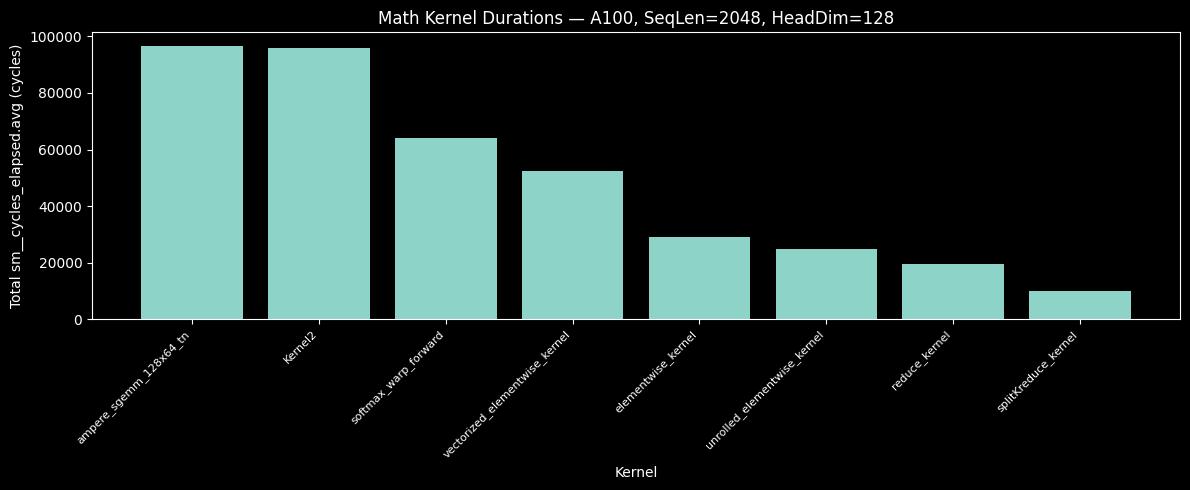

In [27]:
# Example
plot_math_kernel_durations('A100', 2048, 128, show=True)

In [28]:
for gpu_name in GPU_ORDER:
    for seq_len in SEQ_LENS:
        for head_dim in HEAD_DIMS:
            try:
                plot_math_kernel_durations(gpu_name, seq_len, head_dim, save=True)
            except Exception as e:
                print(e)

/var/folders/zp/rr203r4x1vj22lh9pzzc37z80000gn/T/ipykernel_60348/2128400339.py:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()
/var/folders/zp/rr203r4x1vj22lh9pzzc37z80000gn/T/ipykernel_60348/2128400339.py:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()
/var/folders/zp/rr203r4x1vj22lh9pzzc37z80000gn/T/ipykernel_60348/2128400339.py:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()
/var/folders/zp/rr203r4x1vj22lh9pzzc37z80000gn/T/ipykernel_60348/2128400339.py:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()
/var/folders/zp/rr203r4x1vj22lh9pzzc37z80000gn/T/ipykernel_6

Note that `volta_sgemm_*`, `ampere_sgemm_*`, `sm80_xmma_gemm_`, and `Kernel2` kernels are all Matrix Mult

#### FlashAttention-2 Backend

In [29]:
def plot_flash_kernel_durations(gpu_name: str, seq_len: int, head_dim: int,
                                show: bool = False, save: bool = False):
    """
    Bar chart of total sm__cycles_elapsed.avg per FA2 kernel name
    for a single (gpu_name, seq_len, head_dim) config.

    Includes flash_fwd_splitkv_combine_kernel (the reduction step) since
    this is a duration plot and it contributes to total runtime.
    Multiple invocations of the same kernel name are summed.
    """
    _plot_kernel_durations(
        metrics_df_run0_flash_only, gpu_name, seq_len, head_dim,
        title_prefix='FA2', save_dir='flash_kernel_durations',
        show=show, save=save,
    )

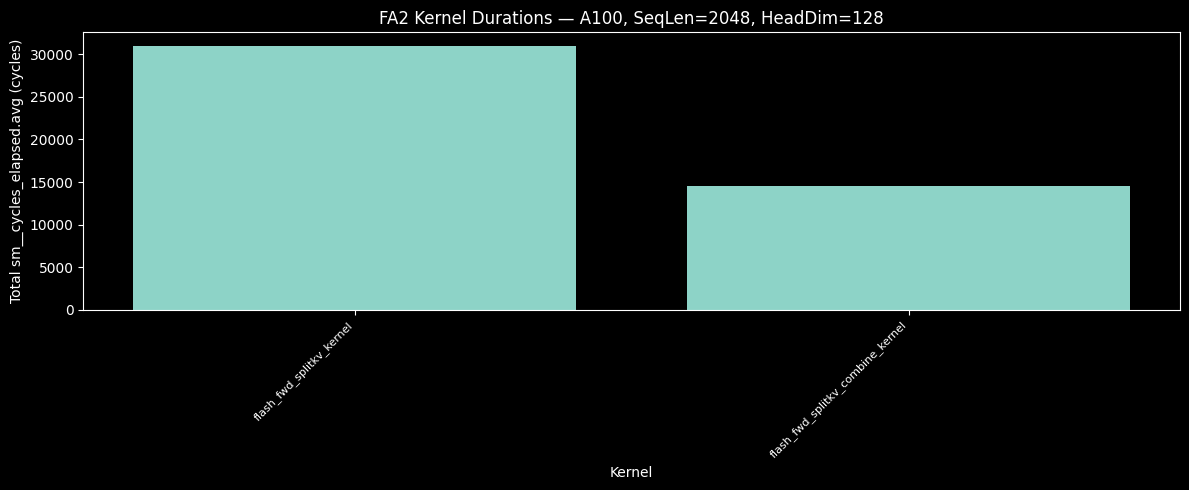

In [30]:
# Example
plot_flash_kernel_durations('A100', 2048, 128, show=True)

In [31]:
for gpu_name in GPU_ORDER:
    for seq_len in SEQ_LENS:
        for head_dim in HEAD_DIMS:
            try:
                plot_flash_kernel_durations(gpu_name, seq_len, head_dim, save=True)
            except Exception as e:
                print(e)

No FA2 kernel data for gpu_name='RTX 2060', seq_len=256, head_dim=64
No FA2 kernel data for gpu_name='RTX 2060', seq_len=256, head_dim=128
No FA2 kernel data for gpu_name='RTX 2060', seq_len=512, head_dim=64
No FA2 kernel data for gpu_name='RTX 2060', seq_len=512, head_dim=128
No FA2 kernel data for gpu_name='RTX 2060', seq_len=1024, head_dim=64
No FA2 kernel data for gpu_name='RTX 2060', seq_len=1024, head_dim=128
No FA2 kernel data for gpu_name='RTX 2060', seq_len=2048, head_dim=64
No FA2 kernel data for gpu_name='RTX 2060', seq_len=2048, head_dim=128
No FA2 kernel data for gpu_name='RTX 2060', seq_len=4096, head_dim=64
No FA2 kernel data for gpu_name='RTX 2060', seq_len=4096, head_dim=128
No FA2 kernel data for gpu_name='RTX 2060', seq_len=8192, head_dim=64
No FA2 kernel data for gpu_name='RTX 2060', seq_len=8192, head_dim=128
No FA2 kernel data for gpu_name='T4', seq_len=256, head_dim=64
No FA2 kernel data for gpu_name='T4', seq_len=256, head_dim=128
No FA2 kernel data for gpu_name

## Plot Utilization of Function Units

### Setup

In [32]:
KERNEL_ORDER = ['Math', 'xformers', 'FA2', 'cuDNN']


def label_kernel(name: str):
    """
    Only needed for CuDNN and MEA.
    Math and FA2 backends are covered separately because they are aggregated.
    """
    if 'cudnn_generated' in name:
        return 'cuDNN'
    if 'fmha_cutlassF' in name:
        return 'xformers'
    return None

In [33]:
# xformers and cuDNN: per-kernel rows from util_df, averaged over invocations (should only be 1 each)
plot_df = util_df.copy()
plot_df['KernelLabel'] = plot_df['Action'].apply(label_kernel)
plot_df['GpuLabel'] = plot_df['GpuName'].map(GPU_LABELS)
plot_df = plot_df[
    plot_df['KernelLabel'].isin(['xformers', 'cuDNN']) &
    plot_df['GpuLabel'].isin(GPU_ORDER)
    ].copy()
xformers_cudnn_agg = (plot_df
                      .groupby(['GpuLabel', 'KernelLabel', 'SeqLen', 'HeadDim'])[UNIT_COLS]
                      .mean()
                      .reset_index())

# FA2: cycle-weighted aggregate from util_df_flash_only
fa2_df = util_df_flash_only.copy()
fa2_df['KernelLabel'] = 'FA2'
fa2_df['GpuLabel'] = fa2_df['GpuName'].map(GPU_LABELS)
fa2_df = fa2_df[fa2_df['GpuLabel'].isin(GPU_ORDER)][
    ['GpuLabel', 'KernelLabel', 'SeqLen', 'HeadDim'] + UNIT_COLS
    ]

# Math: cycle-weighted aggregate from util_df_math_only
math_df = util_df_math_only.copy()
math_df['KernelLabel'] = 'Math'
math_df['GpuLabel'] = math_df['GpuName'].map(GPU_LABELS)
math_df = math_df[math_df['GpuLabel'].isin(GPU_ORDER)][
    ['GpuLabel', 'KernelLabel', 'SeqLen', 'HeadDim'] + UNIT_COLS
    ]

agg_df = pd.concat([xformers_cudnn_agg, fa2_df, math_df], ignore_index=True)

print(f"agg_df shape: {agg_df.shape}")
print(agg_df.groupby(['KernelLabel', 'GpuLabel']).size().unstack(fill_value=0))

agg_df shape: (240, 18)
GpuLabel     A100  Blackwell  H100  L4  RTX 2060  T4
KernelLabel                                         
FA2            12         12    12  12         0   0
Math           12         12    12  12        12  12
cuDNN          12         12    12  12         0   0
xformers       12         12    12  12        12  12


### Plot util of each Function Unit across GPU and Kernel for certain Seq Len, Head Dim

In [34]:
def plot_util_by_gpu_and_kernel(seq_len: int, head_dim: int, util_col: str, show: bool = False,
                                save: bool = False):
    """
    Bar chart of util_col across kernels and GPUs for a single (seq_len, head_dim) config.
    """
    sub = agg_df[(agg_df['SeqLen'] == seq_len) & (agg_df['HeadDim'] == head_dim)]
    pivot = (sub
             .pivot_table(index='KernelLabel', columns='GpuLabel', values=util_col)
             .reindex(index=KERNEL_ORDER, columns=GPU_ORDER))

    col_label = dict(zip(UNIT_COLS, UNIT_LABELS)).get(util_col, util_col)

    fig, ax = plt.subplots(figsize=(7, 4))
    pivot.plot(kind='bar', ax=ax, width=0.75, rot=25)
    ax.set_title(f'{col_label} Utilization \u2014 SeqLen={seq_len}, HeadDim={head_dim}')
    ax.set_xlabel('')
    ax.set_ylabel(f'{col_label} Utilization (fraction of cycles)')
    ax.set_ylim(0, 1)
    ax.legend(title='GPU', fontsize=8)
    fig.tight_layout()

    if not os.path.exists(f'plots'):
        os.makedirs(f'plots')
    if not os.path.exists(f'plots/util_across_gpu_and_kernel'):
        os.makedirs(f'plots/util_across_gpu_and_kernel')
    if not os.path.exists(f'plots/util_across_gpu_and_kernel/{util_col}'):
        os.makedirs(f'plots/util_across_gpu_and_kernel/{util_col}')

    if save:
        plt.savefig(f'plots/util_across_gpu_and_kernel/{util_col}/{util_col}_{seq_len}x{head_dim}.png')

    if show:
        plt.show()
    else:
        plt.close()

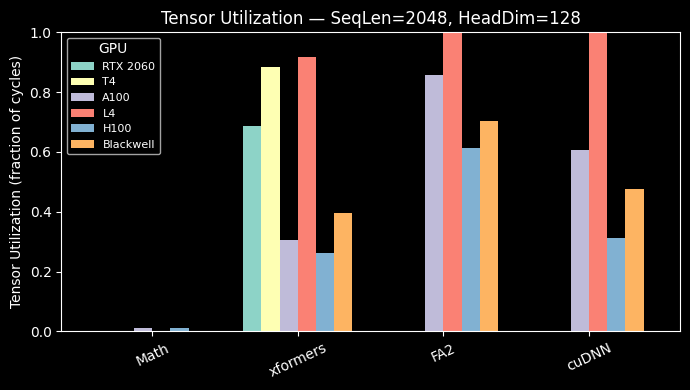

In [35]:
# Example
plot_util_by_gpu_and_kernel(2048, 128, 'Tensor_Util', show=True)

In [36]:
for unit_col in UNIT_COLS:
    print(f"Plotting {unit_col}")
    for seq_len in SEQ_LENS:
        print(f"  Seq len {seq_len}")
        for head_dim in HEAD_DIMS:
            print(f"    Head dim {head_dim}")
            plot_util_by_gpu_and_kernel(seq_len, head_dim, unit_col, save=True)

Plotting ALU_Heavy_Util
  Seq len 256
    Head dim 64
    Head dim 128
  Seq len 512
    Head dim 64
    Head dim 128
  Seq len 1024
    Head dim 64
    Head dim 128
  Seq len 2048
    Head dim 64
    Head dim 128
  Seq len 4096
    Head dim 64
    Head dim 128
  Seq len 8192
    Head dim 64
    Head dim 128
Plotting ALU_Util
  Seq len 256
    Head dim 64
    Head dim 128
  Seq len 512
    Head dim 64
    Head dim 128
  Seq len 1024
    Head dim 64
    Head dim 128
  Seq len 2048
    Head dim 64
    Head dim 128
  Seq len 4096
    Head dim 64
    Head dim 128
  Seq len 8192
    Head dim 64
    Head dim 128
Plotting DRAM_Util
  Seq len 256
    Head dim 64
    Head dim 128
  Seq len 512
    Head dim 64
    Head dim 128
  Seq len 1024
    Head dim 64
    Head dim 128
  Seq len 2048
    Head dim 64
    Head dim 128
  Seq len 4096
    Head dim 64
    Head dim 128
  Seq len 8192
    Head dim 64
    Head dim 128
Plotting FMA_Heavy_Util
  Seq len 256
    Head dim 64
    Head dim 128
  Seq len 

### Plot util of all Function Units for certain GPU, Kernel, Seq Len, Head Dim

In [37]:
def plot_util_all_func_units(gpu_name: str, kernel_name: str, seq_len: int, head_dim: int,
                             show: bool = False, save: bool = False):
    """
    Bar chart of all util_cols for a single (GPU, kernel, seq_len, head_dim) config.
    """
    sub = agg_df[
        (agg_df['GpuLabel'] == gpu_name) &
        (agg_df['KernelLabel'] == kernel_name) &
        (agg_df['SeqLen'] == seq_len) &
        (agg_df['HeadDim'] == head_dim)
        ]

    assert not sub.empty, (
        f"No data for gpu_name='{gpu_name}', kernel_name='{kernel_name}', "
        f"seq_len={seq_len}, head_dim={head_dim}"
    )

    values = sub[UNIT_COLS].iloc[0]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(UNIT_LABELS, values)
    ax.set_title(f'Functional Unit Utilization — {gpu_name}, {kernel_name}, SeqLen={seq_len}, HeadDim={head_dim}')
    ax.set_xlabel('Functional Unit')
    ax.set_ylabel('Utilization (fraction of cycles)')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=30)
    fig.tight_layout()

    if not os.path.exists(f'plots'):
        os.makedirs(f'plots')
    if not os.path.exists(f'plots/util_all_func_units'):
        os.makedirs(f'plots/util_all_func_units')
    if not os.path.exists(f'plots/util_all_func_units/{gpu_name}'):
        os.makedirs(f'plots/util_all_func_units/{gpu_name}')

    if save:
        plt.savefig(f'plots/util_all_func_units/{gpu_name}/{gpu_name}_{kernel_name}_{seq_len}x{head_dim}.png')

    if show:
        plt.show()
    else:
        plt.close()

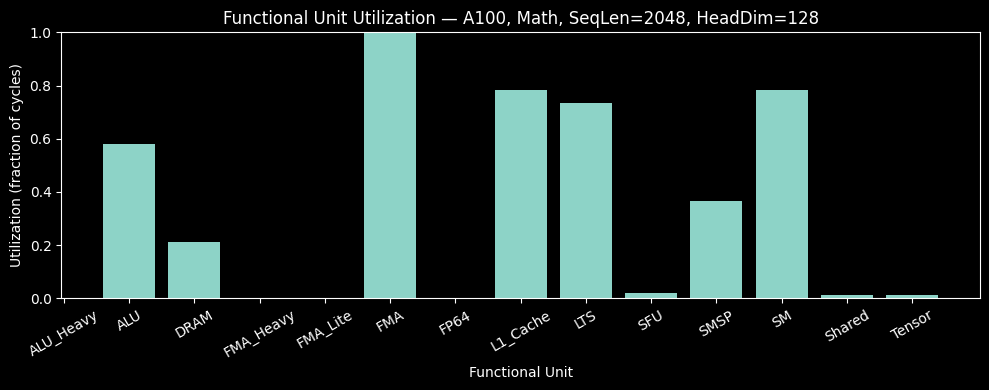

In [38]:
# Example
plot_util_all_func_units('A100', 'Math', 2048, 128, show=True)

In [39]:
for gpu_name in GPU_ORDER:
    print(f"Plotting {gpu_name}")
    for kernel_name in KERNEL_ORDER:
        print(f"  Kernel {kernel_name}")
        for seq_len in SEQ_LENS:
            print(f"    Seq len {seq_len}")
            for head_dim in HEAD_DIMS:
                print(f"      Head dim {head_dim}")
                try:
                    plot_util_all_func_units(gpu_name, kernel_name, seq_len, head_dim, save=True)
                except AssertionError as e:
                    print(f'      {e}')

Plotting RTX 2060
  Kernel Math
    Seq len 256
      Head dim 64
      Head dim 128
    Seq len 512
      Head dim 64
      Head dim 128
    Seq len 1024
      Head dim 64
      Head dim 128
    Seq len 2048
      Head dim 64
      Head dim 128
    Seq len 4096
      Head dim 64
      Head dim 128
    Seq len 8192
      Head dim 64
      Head dim 128
  Kernel xformers
    Seq len 256
      Head dim 64
      Head dim 128
    Seq len 512
      Head dim 64
      Head dim 128
    Seq len 1024
      Head dim 64
      Head dim 128
    Seq len 2048
      Head dim 64
      Head dim 128
    Seq len 4096
      Head dim 64
      Head dim 128
    Seq len 8192
      Head dim 64
      Head dim 128
  Kernel FA2
    Seq len 256
      Head dim 64
      No data for gpu_name='RTX 2060', kernel_name='FA2', seq_len=256, head_dim=64
      Head dim 128
      No data for gpu_name='RTX 2060', kernel_name='FA2', seq_len=256, head_dim=128
    Seq len 512
      Head dim 64
      No data for gpu_name='RTX 2060', 